# Driver / Attribution Model
### Sales Forecasting & Gen AI Project

## 1. Imports

In [2]:
import pandas as pd
import numpy as np

In [3]:
from sqlalchemy import create_engine

## 2. Connect to MySQL & Load Raw Tables

In [4]:
from urllib.parse import quote_plus

In [5]:
DB_USER = "root"
DB_PASSWORD = quote_plus("your password") 
DB_HOST = "localhost"
DB_PORT = 3306
DB_NAME = "your database name"


In [6]:
connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

with engine.connect() as conn:
    sales = pd.read_sql("SELECT * FROM sales_transactions", conn)
    products = pd.read_sql("SELECT product_id, category FROM products", conn)

In [7]:
sales['txn_date'] = pd.to_datetime(sales['txn_date'])
sales['year'] = sales['txn_date'].dt.year
sales['month'] = sales['txn_date'].dt.month

In [8]:
sales = sales.merge(products, on='product_id', how='left')

print("Shape:", sales.shape)
sales.head()

Shape: (8994, 12)


,transaction_id,txn_date,product_id,customer_id,region,quantity,unit_price,discount,revenue,year,month,category
0,T100000,2023-10-13,P0029,C00010,south,1,12773.07,0.0,12773.07,2023,10,home & kitchen
1,T100001,2023-05-29,P0011,C00238,west,6,8863.25,0.0,53179.50,2023,5,grocery
2,T100002,2024-10-02,P0010,C00051,east,3,8164.43,0.0,24493.29,2024,10,sports
3,T100003,2025-09-04,P0030,C00039,north,3,6824.34,0.0,20473.02,2025,9,grocery
4,T100004,2024-03-31,P0009,C00126,west,6,11247.70,0.0,67486.20,2024,3,home & kitchen


## 3. Build Slice-Level Table (month x region x category)

In [9]:
slices = (
    sales
    .groupby(['year', 'month', 'region', 'category'], as_index=False)
    .agg(
        revenue=('revenue', 'sum'),
        avg_discount=('discount', 'mean'),
        order_count=('transaction_id', 'count'),
        active_customers=('customer_id', 'nunique')
    )
)

In [10]:
slices = slices.sort_values(['region', 'category', 'year', 'month']).reset_index(drop=True)

print("Shape:", slices.shape)
slices.head(10)


Shape: (1074, 8)


,year,month,region,category,revenue,avg_discount,order_count,active_customers
0,2023,1,central,apparel,232712.16,0.008333,6,6
1,2023,2,central,apparel,45557.37,0.037500,4,4
2,2023,3,central,apparel,142090.71,0.000000,5,4
3,2023,4,central,apparel,192756.75,0.000000,6,6
4,2023,5,central,apparel,155914.28,0.000000,3,3
5,2023,6,central,apparel,78562.80,0.000000,2,2
6,2023,7,central,apparel,149822.88,0.020000,5,4
7,2023,8,central,apparel,158081.15,0.033333,6,6
8,2023,9,central,apparel,289155.23,0.021429,7,7
9,2023,10,central,apparel,327956.48,0.028571,7,7


## 4. Add Lag & Growth Features

In [11]:
slices['prior_month_revenue'] = (
    slices.groupby(['region', 'category'])['revenue'].shift(1)
)

slices['yoy_revenue'] = (
    slices.groupby(['region', 'category'])['revenue'].shift(12)
)

slices['yoy_growth_pct'] = (
    (slices['revenue'] - slices['yoy_revenue']) / slices['yoy_revenue'] * 100
).round(2)

slices['is_festive_month'] = slices['month'].isin([10, 11, 12]).astype(int)

slices.head(10)


,year,month,region,category,revenue,avg_discount,order_count,active_customers,prior_month_revenue,yoy_revenue,yoy_growth_pct,is_festive_month
0,2023,1,central,apparel,232712.16,0.008333,6,6,NaN,NaN,NaN,0
1,2023,2,central,apparel,45557.37,0.037500,4,4,232712.16,NaN,NaN,0
2,2023,3,central,apparel,142090.71,0.000000,5,4,45557.37,NaN,NaN,0
3,2023,4,central,apparel,192756.75,0.000000,6,6,142090.71,NaN,NaN,0
4,2023,5,central,apparel,155914.28,0.000000,3,3,192756.75,NaN,NaN,0
5,2023,6,central,apparel,78562.80,0.000000,2,2,155914.28,NaN,NaN,0
6,2023,7,central,apparel,149822.88,0.020000,5,4,78562.80,NaN,NaN,0
7,2023,8,central,apparel,158081.15,0.033333,6,6,149822.88,NaN,NaN,0
8,2023,9,central,apparel,289155.23,0.021429,7,7,158081.15,NaN,NaN,0
9,2023,10,central,apparel,327956.48,0.028571,7,7,289155.23,NaN,NaN,1


## 5. Repeat-Customer Rate 


In [12]:
sales_sorted = sales.sort_values('txn_date')
first_purchase = sales_sorted.groupby('customer_id')['txn_date'].min().rename('first_purchase_date')

In [13]:
sales_with_first = sales.merge(first_purchase, on='customer_id', how='left')
sales_with_first['is_repeat'] = (
    sales_with_first['txn_date'] > sales_with_first['first_purchase_date']
).astype(int)


In [14]:
repeat_by_slice = (
    sales_with_first
    .groupby(['year', 'month', 'region', 'category'], as_index=False)
    .agg(repeat_customer_rate=('is_repeat', 'mean'))
)
repeat_by_slice['repeat_customer_rate'] = (repeat_by_slice['repeat_customer_rate'] * 100).round(2)


In [15]:
slices = slices.merge(repeat_by_slice, on=['year', 'month', 'region', 'category'], how='left')
slices.head(10)

,year,month,region,category,revenue,avg_discount,order_count,active_customers,prior_month_revenue,yoy_revenue,yoy_growth_pct,is_festive_month,repeat_customer_rate
0,2023,1,central,apparel,232712.16,0.008333,6,6,NaN,NaN,NaN,0,83.33
1,2023,2,central,apparel,45557.37,0.037500,4,4,232712.16,NaN,NaN,0,50.00
2,2023,3,central,apparel,142090.71,0.000000,5,4,45557.37,NaN,NaN,0,100.00
3,2023,4,central,apparel,192756.75,0.000000,6,6,142090.71,NaN,NaN,0,83.33
4,2023,5,central,apparel,155914.28,0.000000,3,3,192756.75,NaN,NaN,0,100.00
5,2023,6,central,apparel,78562.80,0.000000,2,2,155914.28,NaN,NaN,0,100.00
6,2023,7,central,apparel,149822.88,0.020000,5,4,78562.80,NaN,NaN,0,100.00
7,2023,8,central,apparel,158081.15,0.033333,6,6,149822.88,NaN,NaN,0,100.00
8,2023,9,central,apparel,289155.23,0.021429,7,7,158081.15,NaN,NaN,0,100.00
9,2023,10,central,apparel,327956.48,0.028571,7,7,289155.23,NaN,NaN,1,100.00


## 6. Clean Rows & Encode Categorical Features

In [16]:
slices_clean = slices.dropna().reset_index(drop=True)

slices_encoded = pd.get_dummies(slices_clean, columns=['region', 'category'], drop_first=False)

print("Rows before:", slices.shape[0], "| After cleaning:", slices_clean.shape[0])
slices_encoded.head()


Rows before: 1074 | After cleaning: 714


,year,month,revenue,avg_discount,order_count,active_customers,prior_month_revenue,yoy_revenue,yoy_growth_pct,is_festive_month,...,region_east,region_north,region_south,region_west,category_apparel,category_beauty,category_electronics,category_grocery,category_home & kitchen,category_sports
0,2024,1,125680.34,0.050000,6,6,144284.34,232712.16,-45.99,0,...,False,False,False,False,True,False,False,False,False,False
1,2024,2,75640.04,0.000000,2,2,125680.34,45557.37,66.03,0,...,False,False,False,False,True,False,False,False,False,False
2,2024,3,184481.00,0.656250,8,6,75640.04,142090.71,29.83,0,...,False,False,False,False,True,False,False,False,False,False
3,2024,4,372335.92,0.042857,7,7,184481.00,192756.75,93.16,0,...,False,False,False,False,True,False,False,False,False,False
4,2024,5,181920.50,3.000000,5,5,372335.92,155914.28,16.68,0,...,False,False,False,False,True,False,False,False,False,False


## 7. Define Features (X) and Target (y)


In [17]:
exclude_columns = ['year', 'month', 'revenue', 'yoy_revenue']
feature_columns = [c for c in slices_encoded.columns if c not in exclude_columns]

X = slices_encoded[feature_columns]
y = slices_encoded['revenue']

print("Features used:", feature_columns)
print("X shape:", X.shape)


Features used: ['avg_discount', 'order_count', 'active_customers', 'prior_month_revenue', 'yoy_growth_pct', 'is_festive_month', 'repeat_customer_rate', 'region_central', 'region_east', 'region_north', 'region_south', 'region_west', 'category_apparel', 'category_beauty', 'category_electronics', 'category_grocery', 'category_home & kitchen', 'category_sports']
X shape: (714, 18)


## 8. Train Random Forest 

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

driver_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
driver_model.fit(X_train, y_train)

train_score = driver_model.score(X_train, y_train)
test_score = driver_model.score(X_test, y_test)

print(f"Train R²: {train_score:.3f}")
print(f"Test R²:  {test_score:.3f}")


Train R²: 0.879
Test R²:  0.732


## 9. SHAP — Which Features Actually Drive Revenue?

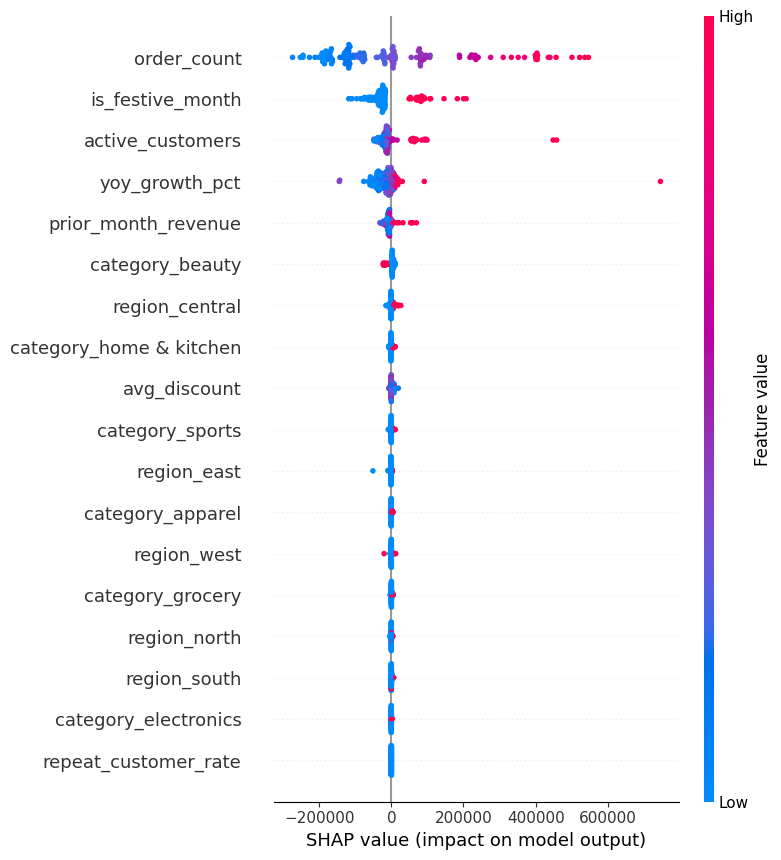

In [19]:
explainer = shap.TreeExplainer(driver_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=True)


## 10. Overall Feature Importance (Ranked Table)


In [20]:
importance_df = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top drivers of revenue (overall):")
importance_df


Top drivers of revenue (overall):


,feature,mean_abs_shap
1,order_count,152778.758968
5,is_festive_month,48054.174884
2,active_customers,29909.039606
4,yoy_growth_pct,27949.824317
3,prior_month_revenue,9746.578475
13,category_beauty,6419.167244
7,region_central,3774.605990
16,category_home & kitchen,2438.313932
0,avg_discount,2068.274669
17,category_sports,1591.533644


## 11. Find Underperforming Slices

In [21]:
latest_year = slices_clean['year'].max()

underperforming = (
    slices_clean[slices_clean['year'] == latest_year]
    .sort_values('yoy_growth_pct')
    .head(5)
)

print(f"Top 5 underperforming region-category slices in {latest_year}:")
underperforming[['year', 'month', 'region', 'category', 'revenue', 'yoy_growth_pct']]


Top 5 underperforming region-category slices in 2025:


,year,month,region,category,revenue,yoy_growth_pct
324,2025,5,north,beauty,12411.24,-92.01
633,2025,4,west,electronics,18297.02,-90.93
84,2025,3,central,grocery,65651.05,-86.69
141,2025,12,central,sports,572425.33,-85.59
42,2025,8,central,beauty,22585.69,-85.28


## 12. Explain One Underperforming Slice (SHAP Force Plot)

Row details:
region               north
category            beauty
year                  2025
month                    5
revenue           12411.24
yoy_growth_pct      -92.01
Name: 324, dtype: object



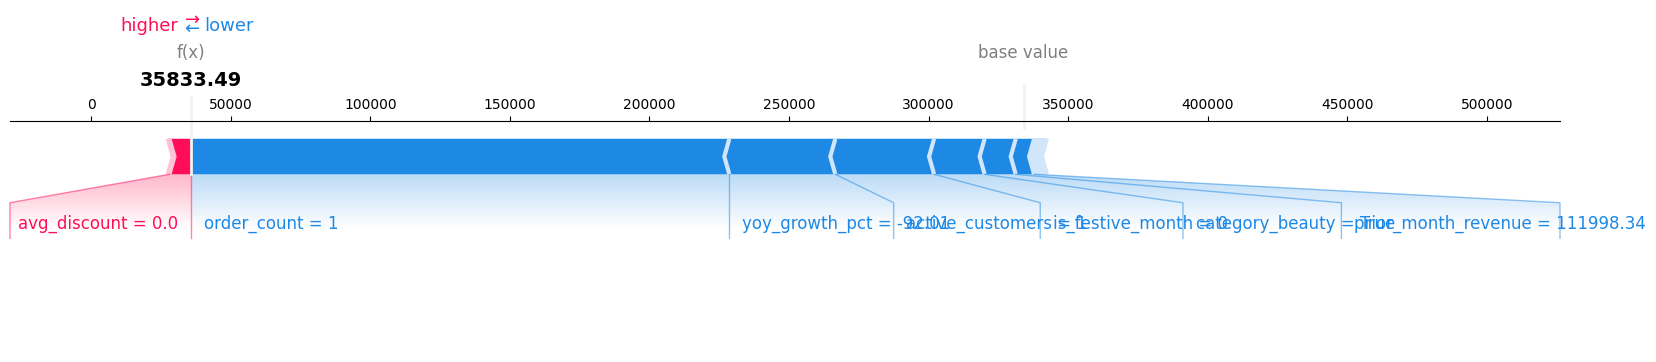

In [24]:
sample_index = underperforming.index[0]

if sample_index in X.index:
    sample_row = X.loc[[sample_index]]
    sample_shap = explainer.shap_values(sample_row)

    print("Row details:")
    print(slices_clean.loc[sample_index, ['region', 'category', 'year', 'month', 'revenue', 'yoy_growth_pct']])
    print()

    shap.force_plot(explainer.expected_value, sample_shap[0], sample_row, matplotlib=True)
else:
    print("Ye specific row is not present in test data. try another underperforming row se.")


In [25]:
import pickle

In [26]:
pickle.dump(driver_model,open("driver_model_RF.pkl",'wb'))